In [1]:
import os
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

In [2]:
DATA_DIR = Path("/mnt/g/rice-leaf-disease-xai/data/Rice Dataset")
print(os.listdir(DATA_DIR))

['Augmented Dataset', 'Original Dataset']


In [3]:
DATA_DIR = Path("/mnt/g/rice-leaf-disease-xai/data/Rice Dataset/Original Dataset")
CLASSES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
CLASSES = [c for c in CLASSES if c != "Rice"]
print("Detected classes:", CLASSES)
print("Total classes:", len(CLASSES))

Detected classes: ['Healthy', 'Insect', 'Leaf Scald', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes', 'Rice Tungro']
Total classes: 7


In [4]:
counts = {}
for cls in CLASSES:
    cls_dir = DATA_DIR / cls
    imgs = [f for f in cls_dir.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    counts[cls] = len(imgs)

df_counts = pd.DataFrame(list(counts.items()), columns=["class", "count"]).sort_values("count", ascending=False)
print(df_counts)
print("Total images:", df_counts["count"].sum())

             class  count
3       Rice Blast    696
0          Healthy    603
2       Leaf Scald    421
1           Insect    281
5     Rice Stripes    266
4  Rice Leaffolder    247
6      Rice Tungro    239
Total images: 2753


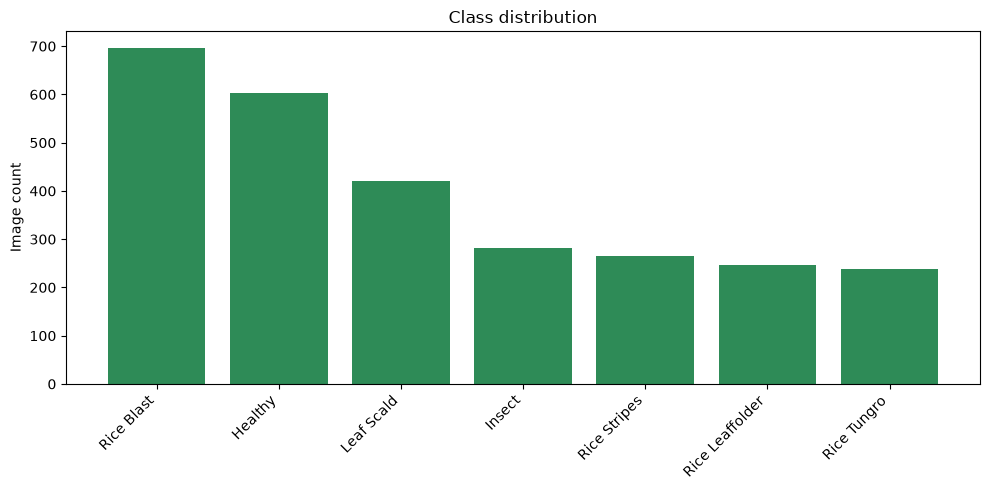

In [5]:
plt.figure(figsize=(10,5))
plt.bar(df_counts["class"], df_counts["count"], color="seagreen")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Image count")
plt.title("Class distribution")
plt.tight_layout()
plt.show()

In [6]:
max_c = df_counts["count"].max()
min_c = df_counts["count"].min()
print("Imbalance ratio (max/min):", round(max_c/min_c, 2))

Imbalance ratio (max/min): 2.91


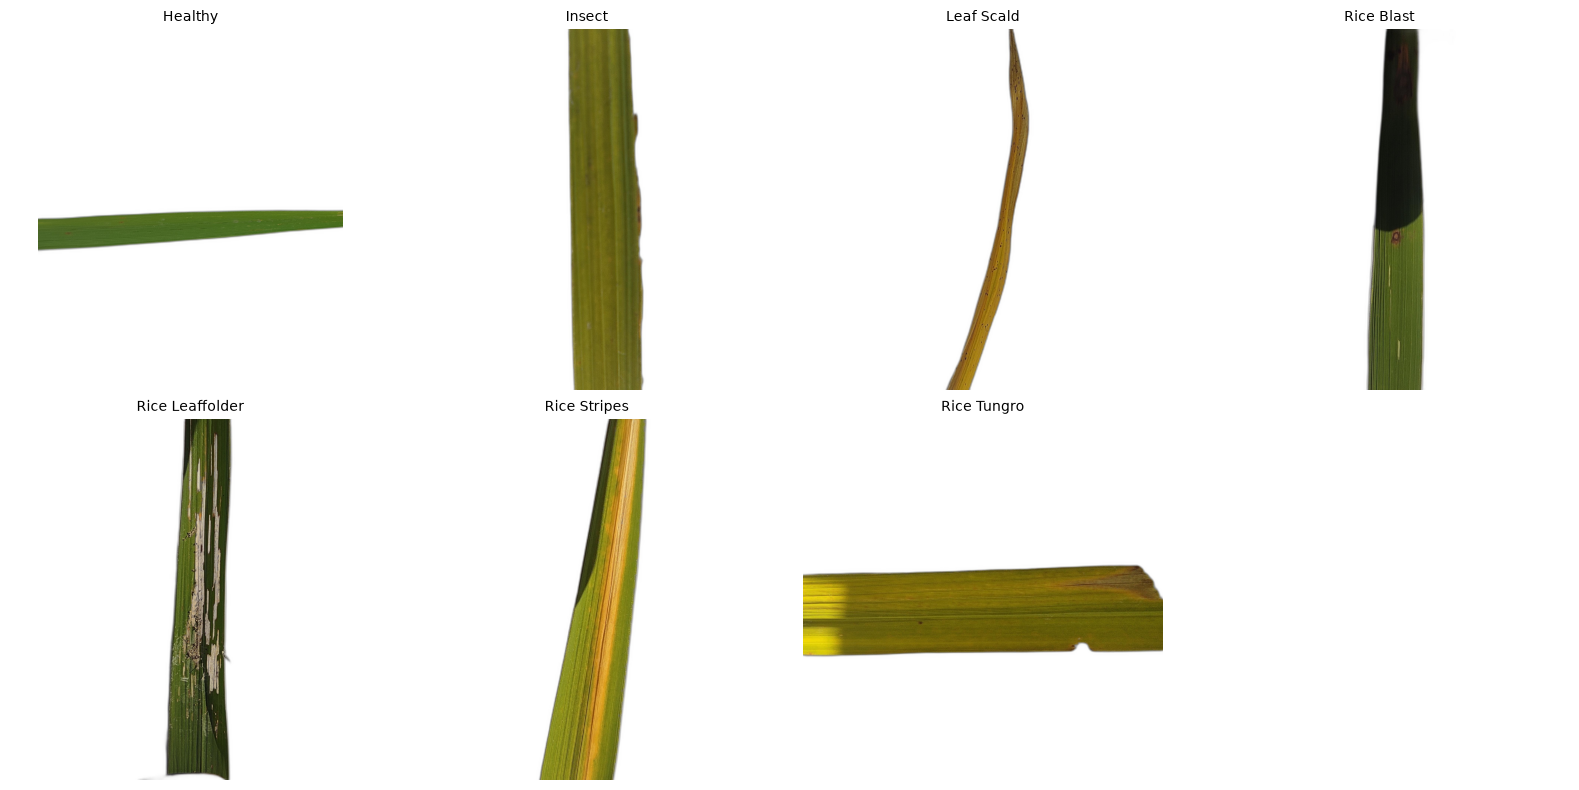

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16,8))
axes = axes.flatten()

for i, cls in enumerate(CLASSES):
    cls_dir = DATA_DIR / cls
    img_path = next(f for f in cls_dir.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"])
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis("off")

for j in range(len(CLASSES), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [8]:
sizes = []
for cls in CLASSES:
    cls_dir = DATA_DIR / cls
    for f in cls_dir.iterdir():
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            try:
                with Image.open(f) as im:
                    sizes.append(im.size)
            except Exception as e:
                print("Error:", f, e)

sizes_arr = np.array(sizes)
print("Unique sizes:", len(set(sizes)))
print("Width  - min/max/mean:", sizes_arr[:,0].min(), sizes_arr[:,0].max(), sizes_arr[:,0].mean())
print("Height - min/max/mean:", sizes_arr[:,1].min(), sizes_arr[:,1].max(), sizes_arr[:,1].mean())

Unique sizes: 851
Width  - min/max/mean: 293 4064 1823.2470032691608
Height - min/max/mean: 306 4160 1873.3668725027244


In [9]:
corrupt = []
for cls in CLASSES:
    cls_dir = DATA_DIR / cls
    for f in cls_dir.iterdir():
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            try:
                img = Image.open(f)
                img.verify()
            except Exception:
                corrupt.append(str(f))

print("Corrupted images found:", len(corrupt))
if corrupt:
    print(corrupt)

Corrupted images found: 0


In [10]:
formats = Counter()
modes = Counter()
for cls in CLASSES:
    cls_dir = DATA_DIR / cls
    for f in cls_dir.iterdir():
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            with Image.open(f) as im:
                formats[im.format] += 1
                modes[im.mode] += 1

print("Formats:", formats)
print("Color modes:", modes)

Formats: Counter({'JPEG': 2282, 'PNG': 471})
Color modes: Counter({'RGB': 2282, 'RGBA': 471})


In [11]:
df_counts.to_csv("eda_class_distribution.csv", index=False)
print("Saved: eda_class_distribution.csv")

Saved: eda_class_distribution.csv
